# Hall Petch

Data From:
[1] Alfred, Samuel Onimpa, and Veera Sundararaghavan. "From Data to Theory: Autonomous Large Language Model Agents for Materials Science." arXiv preprint arXiv:2604.19789 (2026).
[2] https://github.com/samoalfred/LLM-based-Agent/blob/main/Datasets/HP_Dataset.csv
[3] Barnett, M. R., et al. "Influence of grain size on the compressive deformation of wrought Mg–3Al–1Zn." Acta materialia 52.17 (2004): 5093-5103.


  coefficient    estimate  standard_error  ci_95_lower  ci_95_upper  \
0     sigma_0   38.457681        7.652564    21.614502    55.300861   
1         k_y  299.898657       20.766927   254.190960   345.606355   

           unit  
0           MPa  
1  MPa sqrt(um)  

R^2 = 0.9499


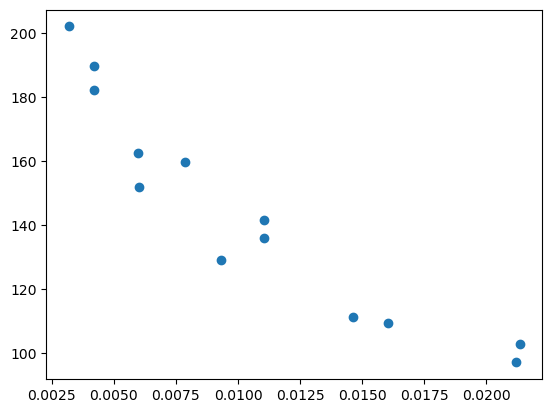

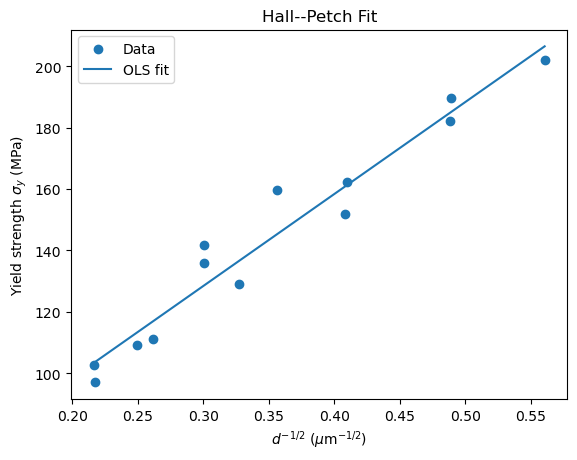

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t


# ------------------------------------------------------------
# Hall--Petch data
# Grain diameter is given in mm.
# Yield strength is given in MPa.
# ------------------------------------------------------------

diameter_mm = np.array([
    0.021356672,
    0.021216922,
    0.016029808,
    0.014637479,
    0.011066638,
    0.011065621,
    0.009327921,
    0.007867989,
    0.005964539,
    0.006007771,
    0.004189118,
    0.004189433,
    0.003184032,
])

sigma_y_MPa = np.array([
    102.7401449,
    97.02443073,
    109.3397925,
    111.2212455,
    135.9043935,
    141.6186514,
    129.1838785,
    159.6016718,
    162.3524957,
    151.8792686,
    189.8126799,
    182.1936693,
    202.0494051,
])

df = pd.DataFrame({
    "diameter_mm": diameter_mm,
    "sigma_y_MPa": sigma_y_MPa
})


fig, ax = plt.subplots(1,1)
ax.scatter(
  x = df["diameter_mm"],
  y = df["sigma_y_MPa"]
)

# ------------------------------------------------------------
# Convert grain size to micrometers
# ------------------------------------------------------------

diameter_um = 1000.0 * diameter_mm


# ------------------------------------------------------------
# Hall--Petch linearizing variable
#
# sigma_y = sigma_0 + k_y d^(-1/2)
#
# Define:
#
# x = d^(-1/2)
#
# Then:
#
# sigma_y = sigma_0 + k_y x
# ------------------------------------------------------------

x = 1.0 / np.sqrt(diameter_um)
y = sigma_y_MPa


# ------------------------------------------------------------
# Construct the design matrix
#
# y = X beta + error
#
# beta = [sigma_0, k_y]^T
# ------------------------------------------------------------

N = len(y)

X = np.column_stack([
    np.ones(N),
    x
])


# ------------------------------------------------------------
# Ordinary least squares solution
#
# beta_hat = (X^T X)^(-1) X^T y
# ------------------------------------------------------------

XtX = X.T @ X
Xty = X.T @ y

beta_hat = np.linalg.solve(XtX, Xty)

sigma_0_hat = beta_hat[0]
k_y_hat = beta_hat[1]


# ------------------------------------------------------------
# Predictions and residuals
# ------------------------------------------------------------

y_hat = X @ beta_hat
residuals = y - y_hat


# ------------------------------------------------------------
# R^2
# ------------------------------------------------------------

SSE = np.sum(residuals**2)
SST = np.sum((y - np.mean(y))**2)

R2 = 1.0 - SSE / SST


# ------------------------------------------------------------
# Coefficient uncertainty
#
# Estimate residual variance:
#
# s^2 = SSE / (N - p)
#
# where p = number of fitted coefficients.
#
# Cov(beta_hat) = s^2 (X^T X)^(-1)
# ------------------------------------------------------------

p = X.shape[1]
dof = N - p

s2 = SSE / dof
cov_beta = s2 * np.linalg.inv(XtX)

standard_errors = np.sqrt(np.diag(cov_beta))


# ------------------------------------------------------------
# 95% confidence intervals for fitted coefficients
# ------------------------------------------------------------

alpha = 0.05
tcrit = t.ppf(1.0 - alpha / 2.0, dof)

ci_lower = beta_hat - tcrit * standard_errors
ci_upper = beta_hat + tcrit * standard_errors


# ------------------------------------------------------------
# Package coefficient table
# ------------------------------------------------------------

coef_table = pd.DataFrame({
    "coefficient": ["sigma_0", "k_y"],
    "estimate": beta_hat,
    "standard_error": standard_errors,
    "ci_95_lower": ci_lower,
    "ci_95_upper": ci_upper,
    "unit": ["MPa", "MPa sqrt(um)"],
})

print(coef_table)
print()
print(f"R^2 = {R2:.4f}")


# ------------------------------------------------------------
# Plot Hall--Petch fit
# ------------------------------------------------------------

x_fit = np.linspace(x.min(), x.max(), 300)
X_fit = np.column_stack([
    np.ones_like(x_fit),
    x_fit
])

y_fit = X_fit @ beta_hat

plt.figure()
plt.scatter(x, y, label="Data")
plt.plot(x_fit, y_fit, label="OLS fit")
plt.xlabel(r"$d^{-1/2}$ $(\mu\mathrm{m}^{-1/2})$")
plt.ylabel(r"Yield strength $\sigma_y$ (MPa)")
plt.title("Hall--Petch Fit")
plt.legend()
plt.show()

In [17]:
import pandas as pd
import scipy.stats 

# Data originally from [3] but extracted by [1] and retrieved from [2]
# [1] Alfred, Samuel Onimpa, and Veera Sundararaghavan. "From Data to Theory: Autonomous Large Language Model Agents for Materials Science." arXiv preprint arXiv:2604.19789 (2026).
# [2] https://github.com/samoalfred/LLM-based-Agent/blob/main/Datasets/HP_Dataset.csv
# [3] Barnett, M. R., et al. "Influence of grain size on the compressive deformation of wrought Mg–3Al–1Zn." Acta materialia 52.17 (2004): 5093-5103.

diameter_mm = np.array([
    0.021356672,
    0.021216922,
    0.016029808,
    0.014637479,
    0.011066638,
    0.011065621,
    0.009327921,
    0.007867989,
    0.005964539,
    0.006007771,
    0.004189118,
    0.004189433,
    0.003184032,
])

sigma_y_MPa = np.array([
    102.7401449,
    97.02443073,
    109.3397925,
    111.2212455,
    135.9043935,
    141.6186514,
    129.1838785,
    159.6016718,
    162.3524957,
    151.8792686,
    189.8126799,
    182.1936693,
    202.0494051,
])

df = pd.DataFrame({
    "diameter_mm": diameter_mm,
    "sigma_y_MPa": sigma_y_MPa
    })

linregress_results \
    = scipy.stats.linregress(
        x=df["diameter_mm"],
        y=df["sigma_y_MPa"]
    )

print(type(linregress_results))
k = linregress_results.slope
k_stderr = linregress_results.stderr
sigma0 = linregress_results.intercept
sigma0_stderr = linregress_results.intercept_stderr
print(f"k = {k:.4f} +/- {k_stderr:0.4f}")
print(f"sigma0 = {sigma0:.4f} +/- {sigma0_stderr:.4f}")
print(linregress_results.rvalue)
print(linregress_results.pvalue)


<class 'scipy.stats._stats_py.LinregressResult'>
k = -5140.9760 +/- 594.3919
sigma0 = 198.0484 +/- 7.1635
-0.9337056074737898
3.0877774498736926e-06
